In [48]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn statsmodels plotly missingno ruptures scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.filters.hp_filter import hpfilter
import ruptures as rpt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

In [61]:
# Load the dataset (adjust path if running locally)
# For Kaggle: '/kaggle/input/datasets/kanchana1990/pypi-aiml-packages-daily-downloads-20252026/pypi_ai_packages.csv'
# For local: './pypi_ai_packages.csv'

FILE_PATH = 'PyPI/pypi_ai_packages.csv'  # Update this path

df = pd.read_csv(FILE_PATH, parse_dates=['date', 'first_release_date'])

# Data cleaning
df['downloads'] = pd.to_numeric(df['downloads'], errors='coerce').fillna(0).astype(int)
df['download_momentum_pct'] = pd.to_numeric(df['download_momentum_pct'], errors='coerce').fillna(0)

print(type(df['date']))

# Extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['dayofweek'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['dayofyear'] = df['date'].dt.dayofyear

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✅ Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"✅ Unique packages: {df['package_name'].nunique():,}")
print(f"✅ Columns: {df.columns.tolist()}")

<class 'pandas.core.series.Series'>
✅ Dataset loaded: 107,329 rows × 26 columns
✅ Date range: 2025-09-22 → 2026-03-21
✅ Unique packages: 299
✅ Columns: ['package_name', 'date', 'year', 'month', 'week', 'download_type', 'downloads', 'version_latest', 'author', 'license', 'license_group', 'summary', 'keywords', 'requires_python', 'dependency_count', 'total_versions', 'first_release_date', 'age_days', 'llm_era_package', 'framework_tag', 'total_downloads', 'avg_daily_downloads', 'download_momentum_pct', 'home_page', 'dayofweek', 'dayofyear']


📦 Filtered to 'without_mirrors': 53,482 rows


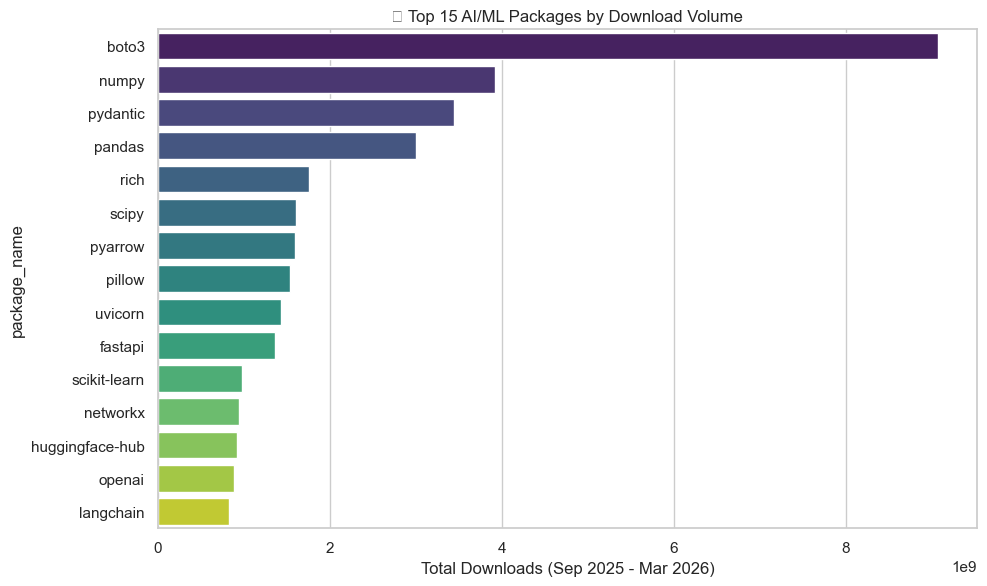

In [50]:
# Filter to direct PyPI downloads only (more reliable signal)
df_clean = df[df['download_type'] == 'without_mirrors'].copy()
print(f"📦 Filtered to 'without_mirrors': {df_clean.shape[0]:,} rows")

# Quick overview of top packages by total downloads
top_packages = df_clean.groupby('package_name')['downloads'].sum().nlargest(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_packages.values, y=top_packages.index, palette='viridis')
plt.xlabel('Total Downloads (Sep 2025 - Mar 2026)')
plt.title('🏆 Top 15 AI/ML Packages by Download Volume')
plt.tight_layout()
plt.show()

📋 Missing Values Summary:
package_name     0
date             0
downloads        0
framework_tag    0
dtype: int64


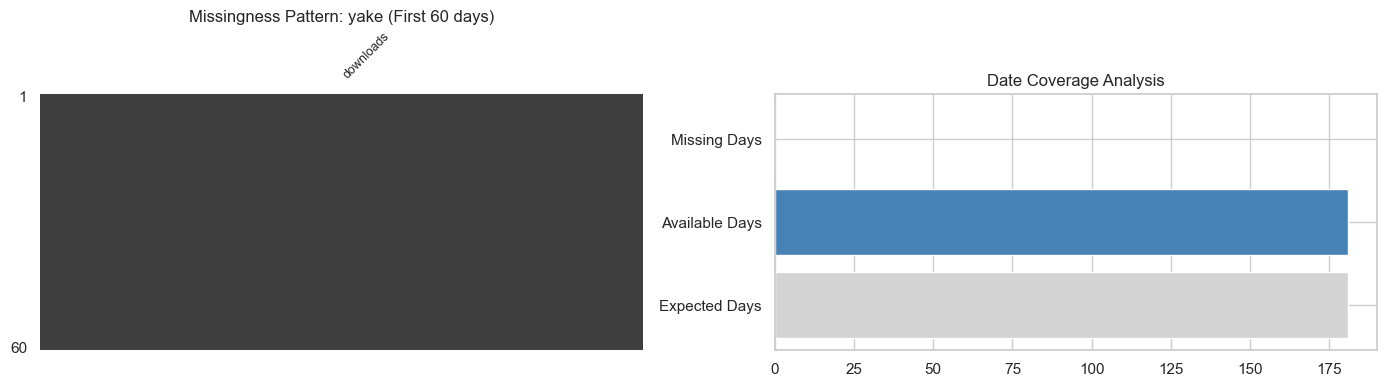


🔍 Sample package 'yake':
   Expected days: 181, Available: 181, Missing: 0


In [64]:
# Check for missing values in key columns
missing_summary = df_clean[['package_name', 'date', 'downloads', 'framework_tag']].isna().sum()
print("📋 Missing Values Summary:")
print(missing_summary)

# Visualize missingness pattern for a sample package
sample_pkg = df_clean['package_name'].value_counts().index[0]  # Most frequent package
sample_df = df_clean[df_clean['package_name'] == sample_pkg].set_index('date').asfreq('D')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
msno.matrix(sample_df[['downloads']].head(60), ax=ax[0], fontsize=9)
ax[0].set_title(f'Missingness Pattern: {sample_pkg} (First 60 days)')

# Check for date gaps
expected_dates = pd.date_range(sample_df.index.min(), sample_df.index.max(), freq='D')
missing_dates = expected_dates.difference(sample_df.index)
ax[1].barh(['Expected Days', 'Available Days', 'Missing Days'], 
           [len(expected_dates), len(sample_df), len(missing_dates)], 
           color=['lightgray', 'steelblue', 'salmon'])
ax[1].set_title('Date Coverage Analysis')
plt.tight_layout()
plt.show()

print(f"\n🔍 Sample package '{sample_pkg}':")
print(f"   Expected days: {len(expected_dates)}, Available: {len(sample_df)}, Missing: {len(missing_dates)}")

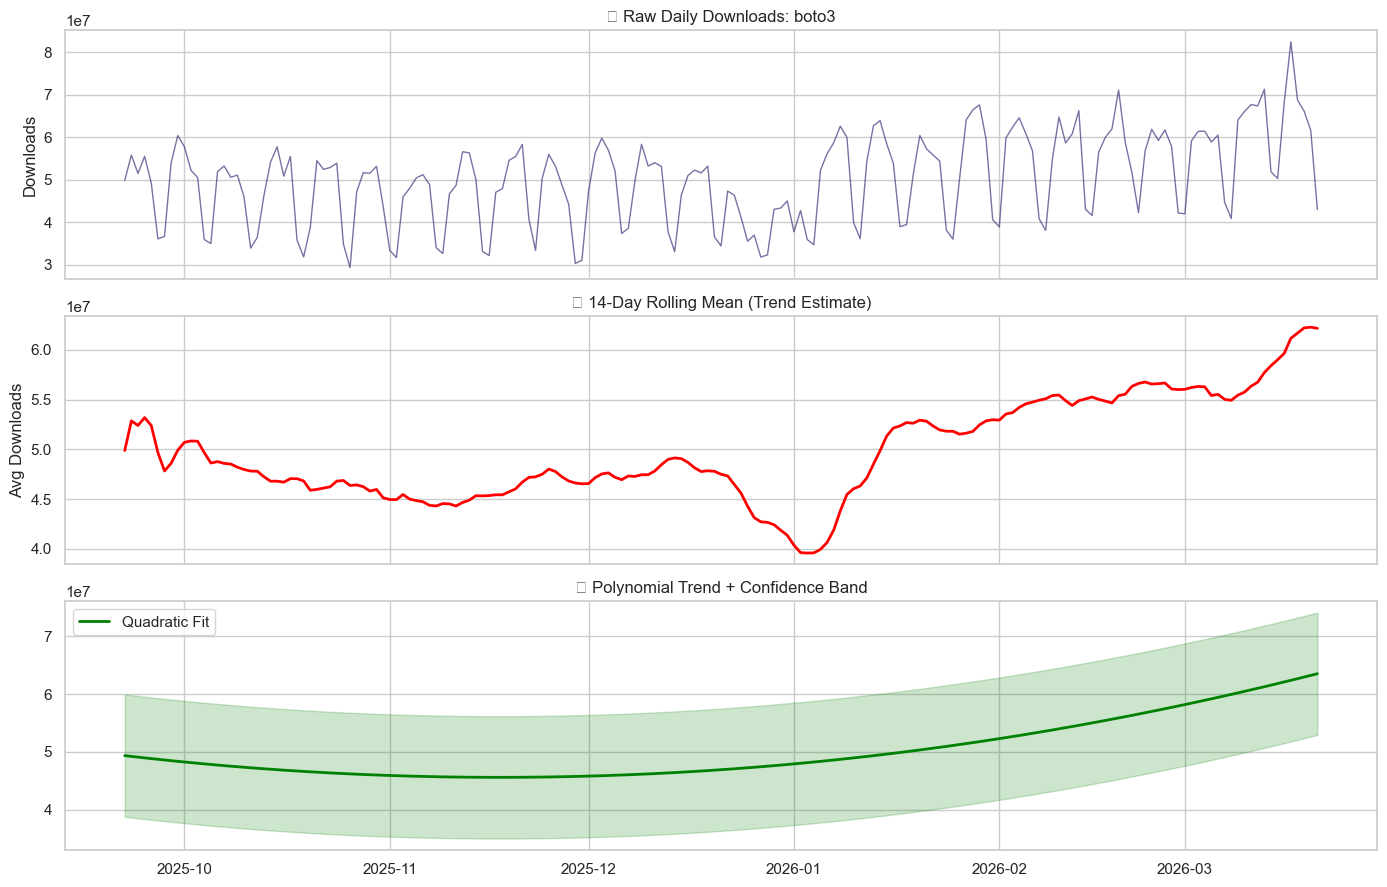

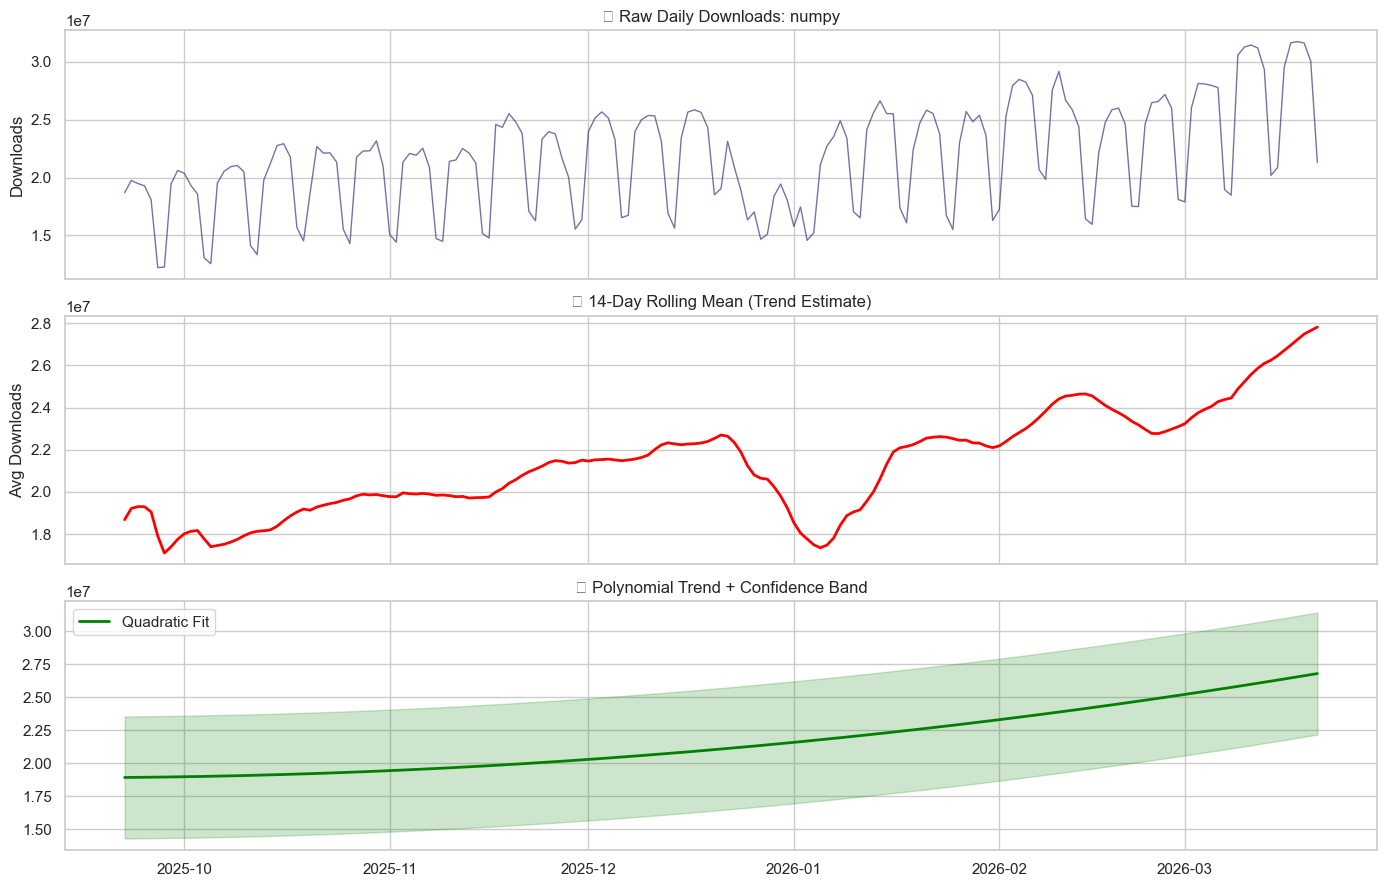

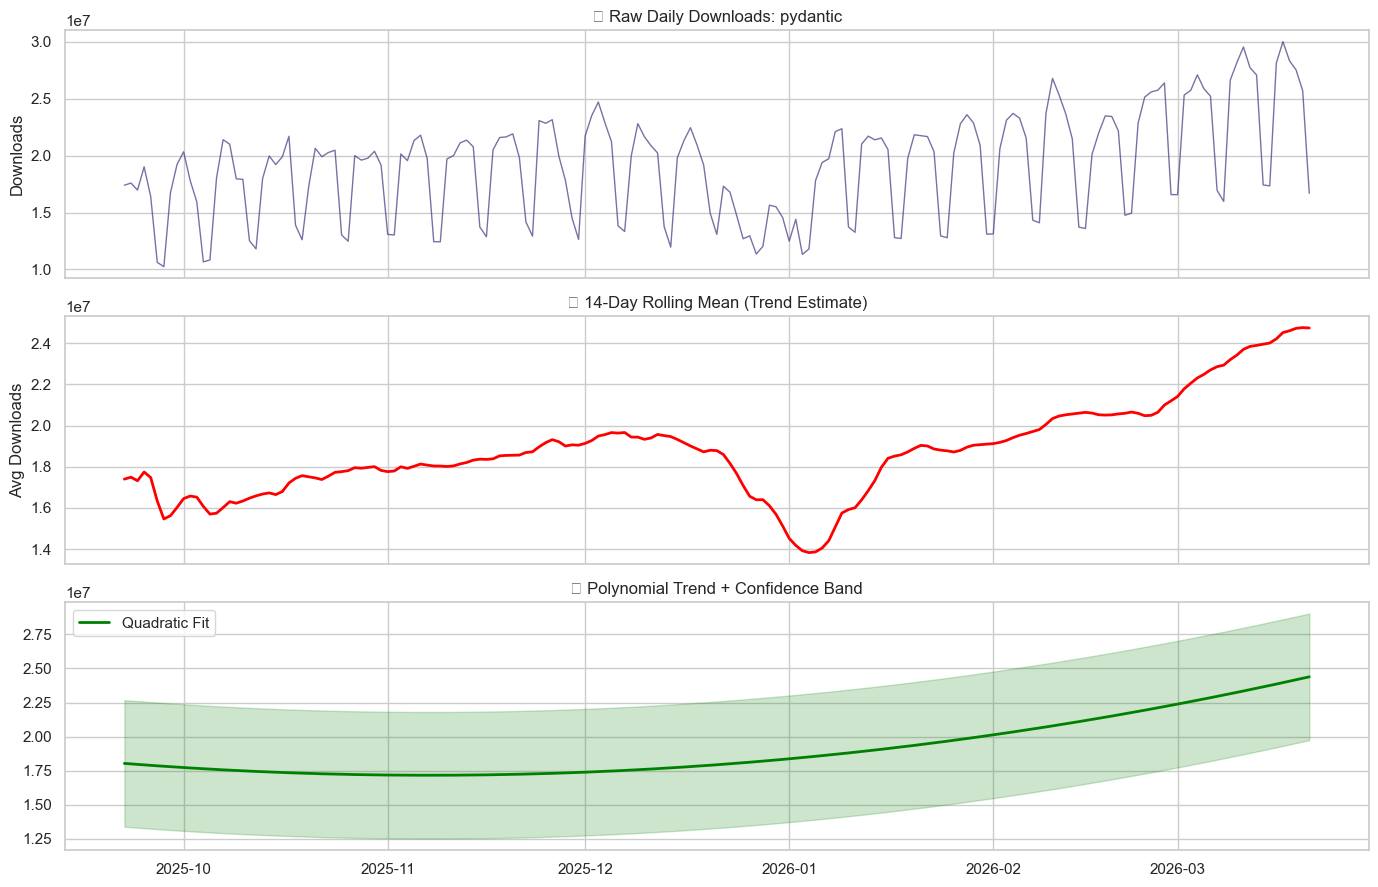

In [ ]:
def plot_trend_analysis(pkg_name, window=14):
    """Plot trend analysis for a single package"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')

    # print(pkg_name)
    
    if len(pkg_data) < 30:
        print(f"⚠️  {pkg_name}: Insufficient data for trend analysis")
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    
    # Raw downloads
    axes[0].plot(pkg_data.index, pkg_data['downloads'], alpha=0.7, linewidth=1)
    axes[0].set_title(f'📊 Raw Daily Downloads: {pkg_name}')
    axes[0].set_ylabel('Downloads')
    
    # Rolling mean (trend)
    pkg_data['rolling_mean'] = pkg_data['downloads'].rolling(window=window, min_periods=1).mean()
    axes[1].plot(pkg_data.index, pkg_data['rolling_mean'], color='red', linewidth=2)
    axes[1].set_title(f'📈 {window}-Day Rolling Mean (Trend Estimate)')
    axes[1].set_ylabel('Avg Downloads')
    
    # Polynomial trend fit
    x = np.arange(len(pkg_data))
    y = pkg_data['downloads'].fillna(method='ffill').values
    if len(y) > 10:
        p = np.polyfit(x[~np.isnan(y)], y[~np.isnan(y)], deg=2)
        trend_fit = np.polyval(p, x)
        axes[2].plot(pkg_data.index, trend_fit, color='green', linewidth=2, label='Quadratic Fit')
        axes[2].fill_between(pkg_data.index, trend_fit - pkg_data['downloads'].std(), 
                           trend_fit + pkg_data['downloads'].std(), alpha=0.2, color='green')
        axes[2].set_title('Polynomial Trend + Confidence Band')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()

# Analyze top 3 packages
for pkg in top_packages.index[:3]:
    plot_trend_analysis(pkg)

In [53]:
# 🌐 Aggregate trend: All packages combined
daily_total = df_clean.groupby('date')['downloads'].sum().reset_index()
daily_total = daily_total.set_index('date').asfreq('D')

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_total.index, y=daily_total['downloads'], 
                        mode='lines', name='Total Daily Downloads', line=dict(width=1)))
fig.add_trace(go.Scatter(x=daily_total.index, 
                        y=daily_total['downloads'].rolling(7, min_periods=1).mean(),
                        mode='lines', name='7-Day MA', line=dict(color='red', width=2)))
fig.update_layout(title='🌐 Ecosystem-Wide Download Trend (All 299 Packages)',
                 xaxis_title='Date', yaxis_title='Total Downloads',
                 hovermode='x unified', template='plotly_white')
fig.show()

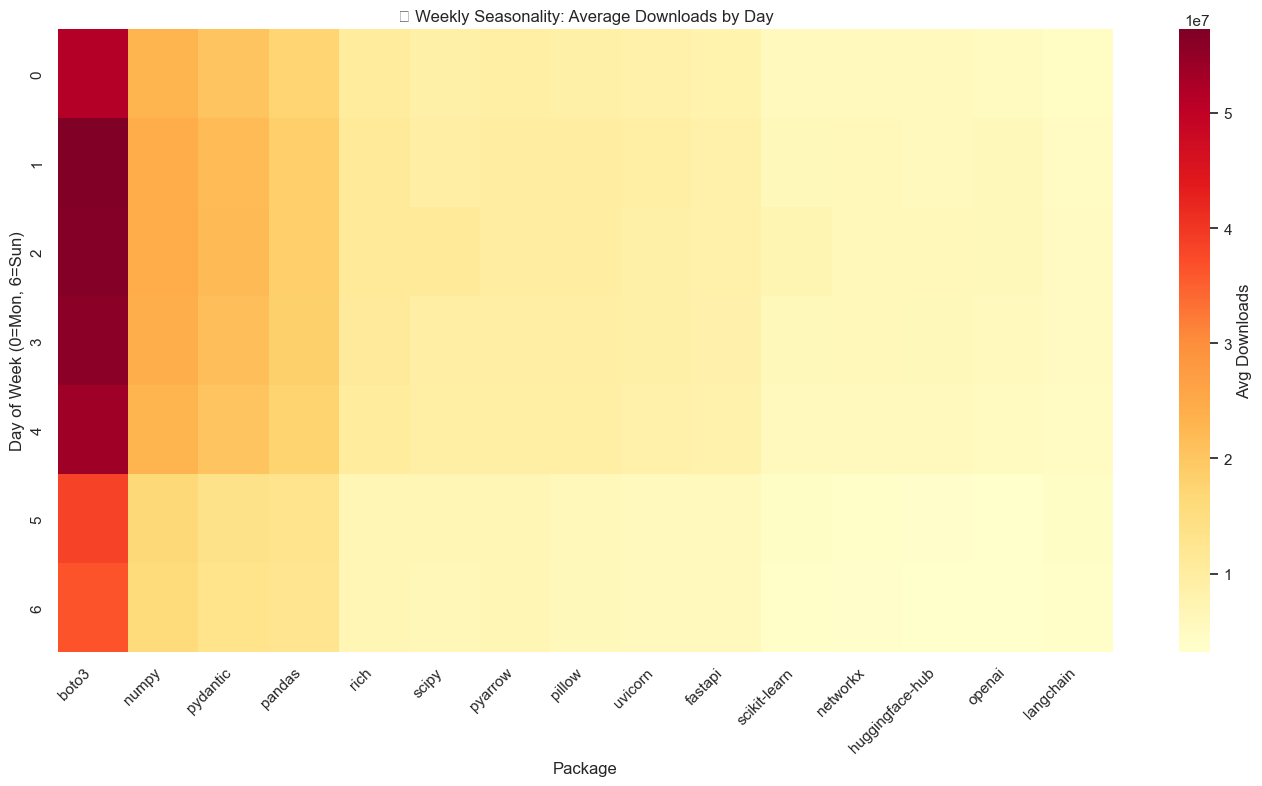

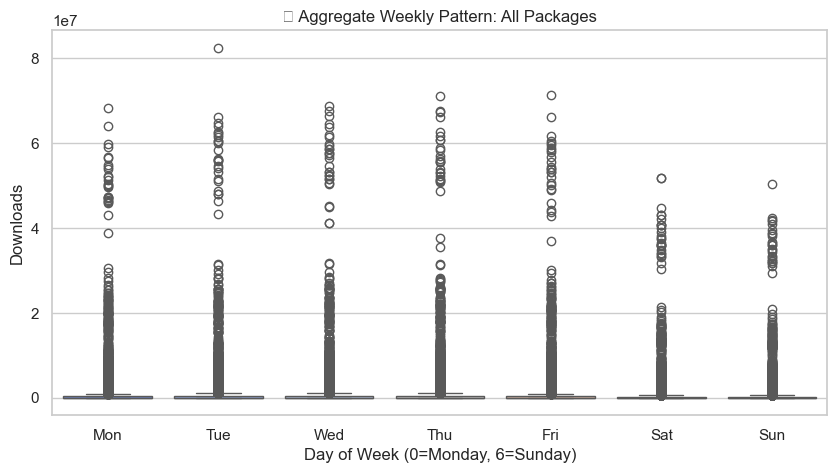

In [66]:
# Weekly seasonality: Downloads by day of week
dow_analysis = df_clean.groupby(['package_name', 'dayofweek'])['downloads'].mean().reset_index()
dow_pivot = dow_analysis.pivot(index='package_name', columns='dayofweek', values='downloads')

# Heatmap of weekly patterns for top 20 packages
plt.figure(figsize=(14, 8))
sns.heatmap(dow_pivot.loc[top_packages.index[:20]].T, 
            cmap='YlOrRd', annot=False, fmt='.0f', cbar_kws={'label': 'Avg Downloads'})
plt.xlabel('Package')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.title('📅 Weekly Seasonality: Average Downloads by Day')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Boxplot: Distribution by day of week (aggregate)
plt.figure(figsize=(10, 5))
sns.boxplot(x='dayofweek', y='downloads', data=df_clean, 
            order=[0,1,2,3,4,5,6], palette='coolwarm')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Downloads')
plt.title('📦 Aggregate Weekly Pattern: All Packages')
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.show()

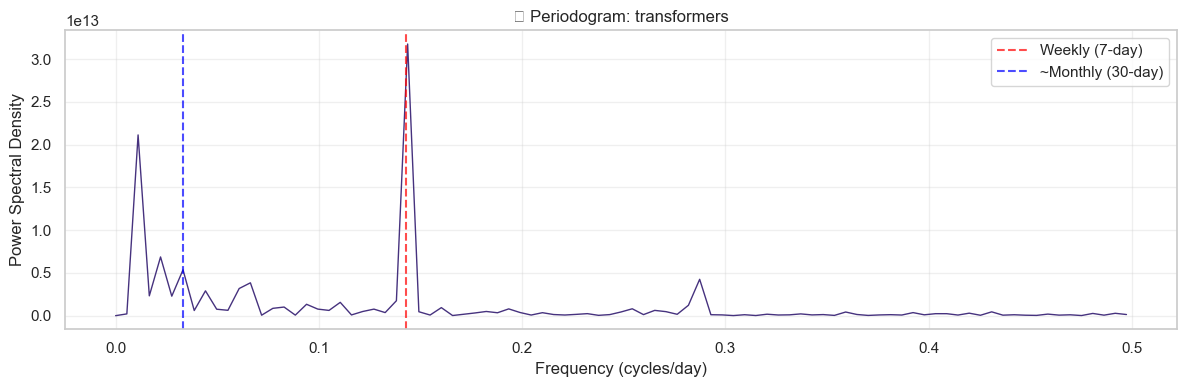

In [55]:
# 🎵 Periodogram: Detect dominant frequencies
from scipy import signal

def plot_periodogram(pkg_name, max_lag=90):
    """Spectral analysis to find seasonal periods"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].fillna(method='ffill').values
    
    if len(series) < 30:
        return
    
    # Compute periodogram
    freqs, power = signal.periodogram(series, fs=1)  # fs=1 cycle/day
    
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, power, linewidth=1)
    plt.axvline(1/7, color='red', linestyle='--', alpha=0.7, label='Weekly (7-day)')
    plt.axvline(1/30, color='blue', linestyle='--', alpha=0.7, label='~Monthly (30-day)')
    plt.xlabel('Frequency (cycles/day)')
    plt.ylabel('Power Spectral Density')
    plt.title(f'🔊 Periodogram: {pkg_name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Check periodogram for a popular package
plot_periodogram('transformers')

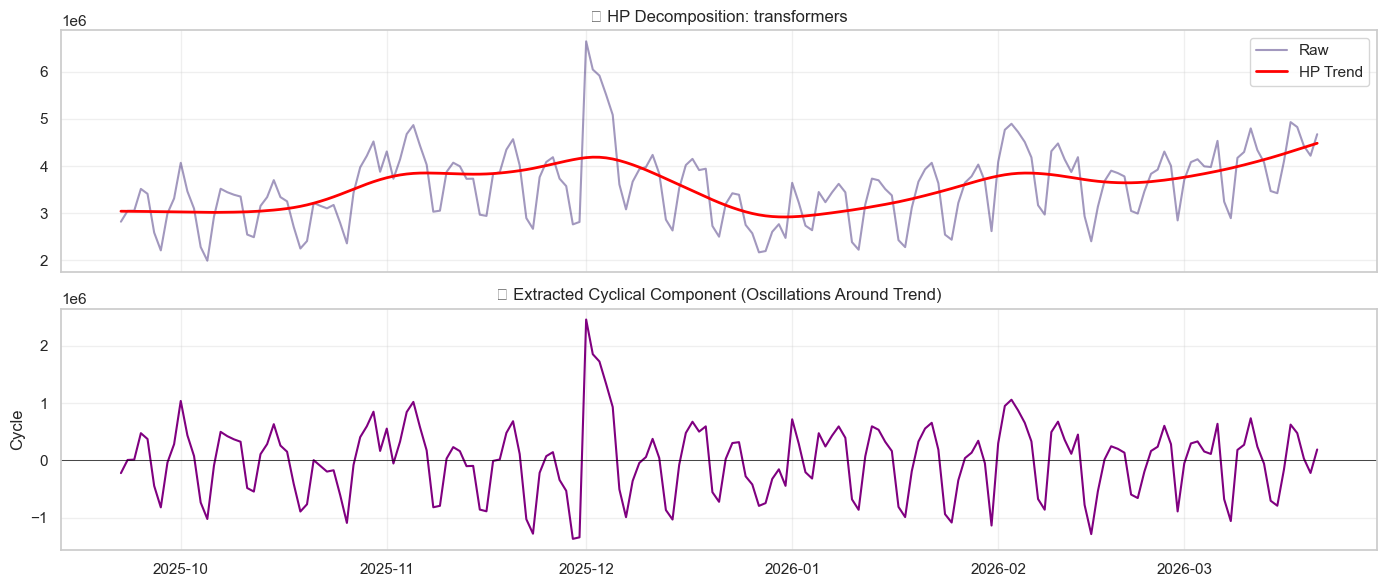

📊 transformers: Cycle amplitude (std) = 629,504 downloads


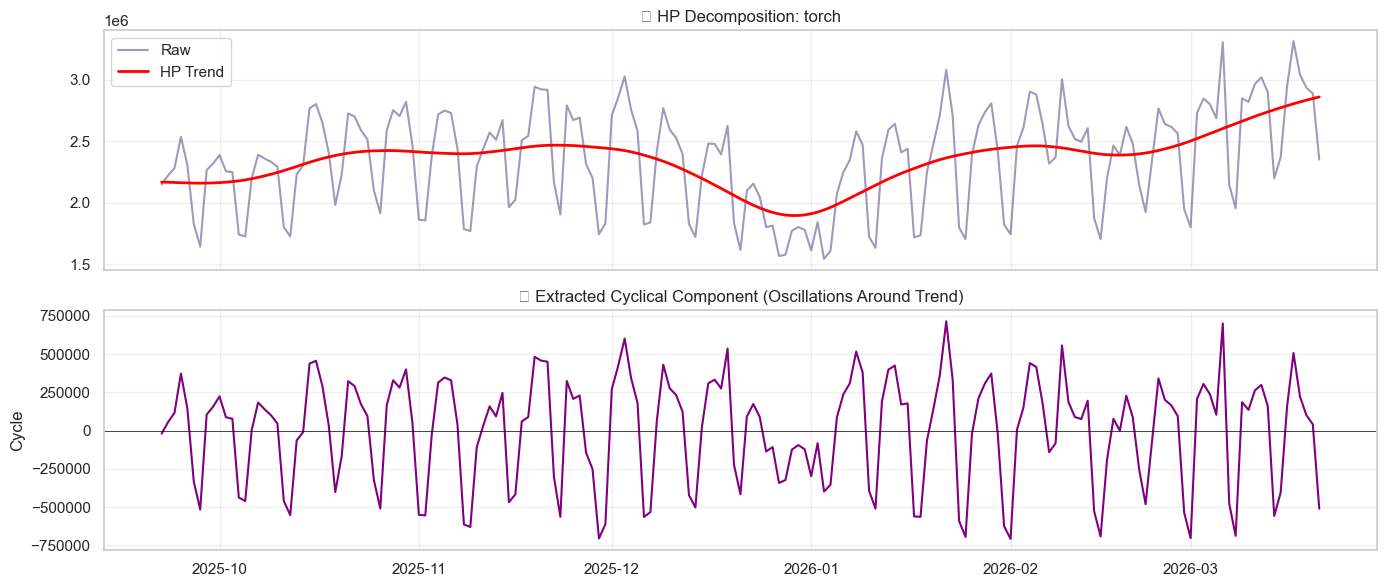

📊 torch: Cycle amplitude (std) = 348,650 downloads


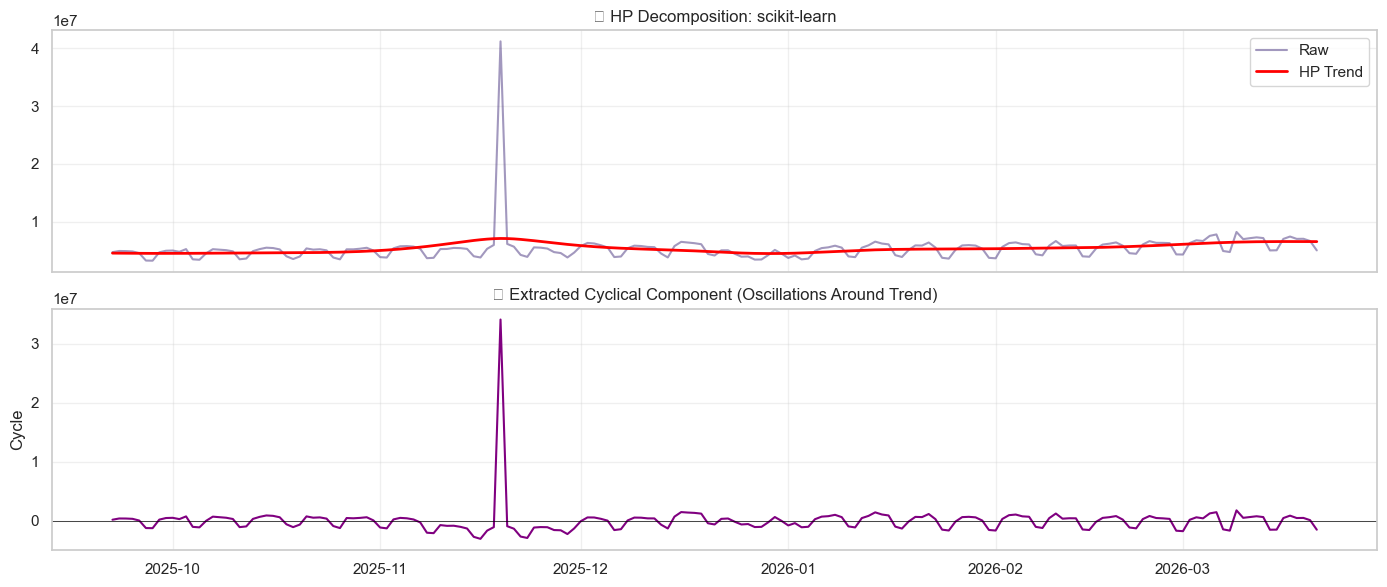

📊 scikit-learn: Cycle amplitude (std) = 2,739,271 downloads


In [56]:
def extract_cycle_component(pkg_name):
    """Extract cyclical component using Hodrick-Prescott filter"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna()
    
    if len(series) < 50:
        print(f"⚠️  {pkg_name}: Too short for cycle extraction")
        return
    
    # HP filter: lambda=1600 for daily data (standard for economic time series)
    cycle, trend = hpfilter(series, lamb=1600)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(series.index, series.values, alpha=0.5, label='Raw')
    axes[0].plot(series.index, trend, color='red', linewidth=2, label='HP Trend')
    axes[0].set_title(f'📈 HP Decomposition: {pkg_name}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(series.index, cycle, color='purple', linewidth=1.5)
    axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_title('🔄 Extracted Cyclical Component (Oscillations Around Trend)')
    axes[1].set_ylabel('Cycle')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Quantify cycle amplitude
    cycle_std = cycle.std()
    print(f"📊 {pkg_name}: Cycle amplitude (std) = {cycle_std:,.0f} downloads")

# Analyze cycles for top packages
for pkg in ['transformers', 'torch', 'scikit-learn']:
    if pkg in df_clean['package_name'].values:
        extract_cycle_component(pkg)

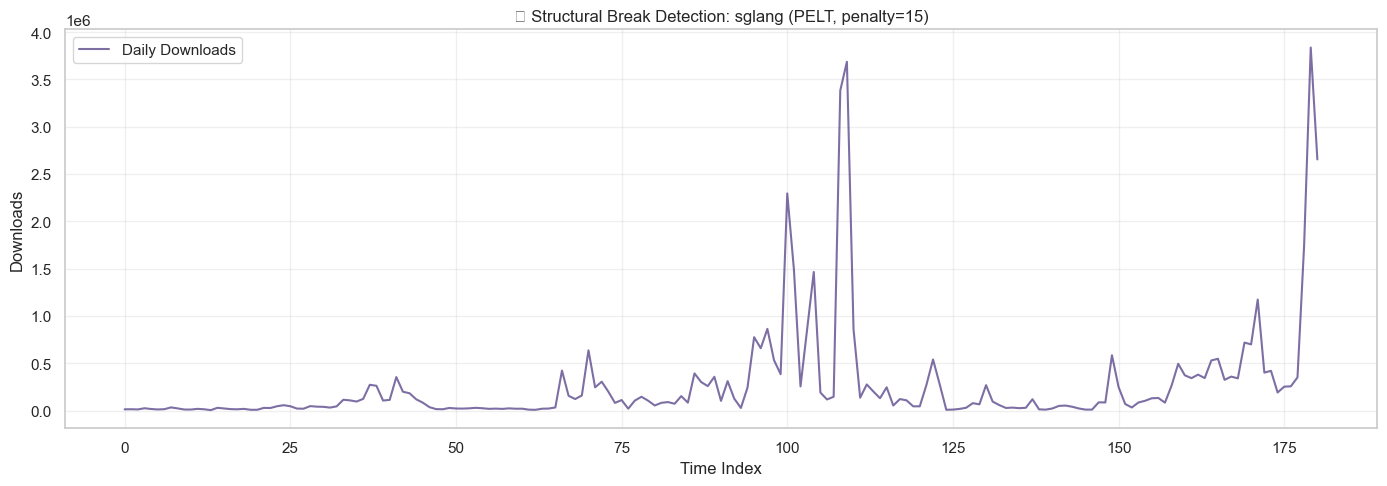

📍 Detected 0 change points for sglang
   Break dates: []


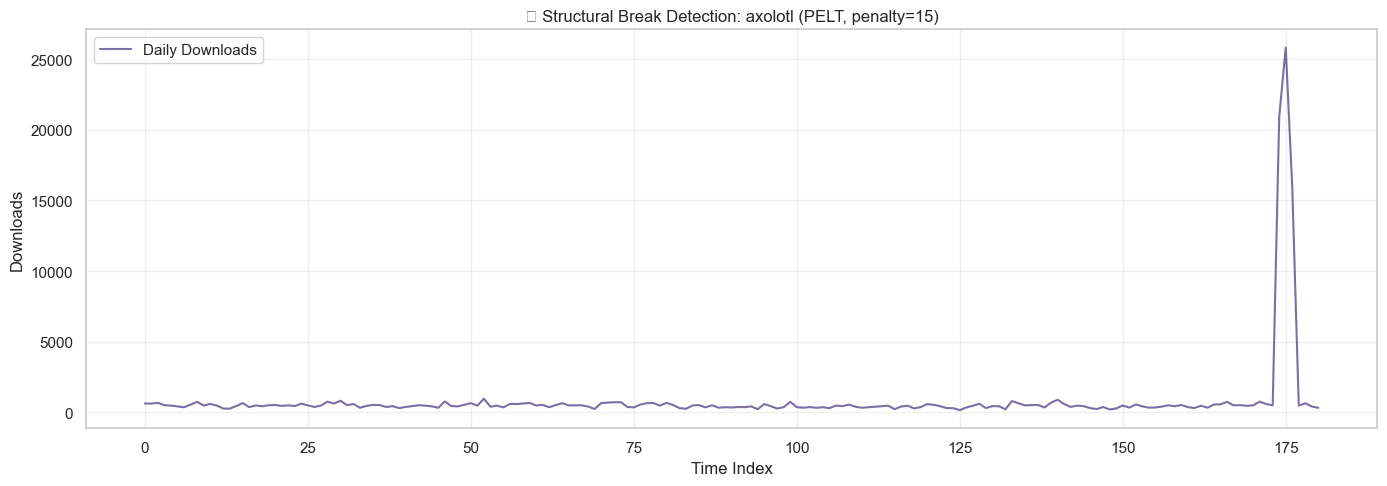

📍 Detected 0 change points for axolotl
   Break dates: []


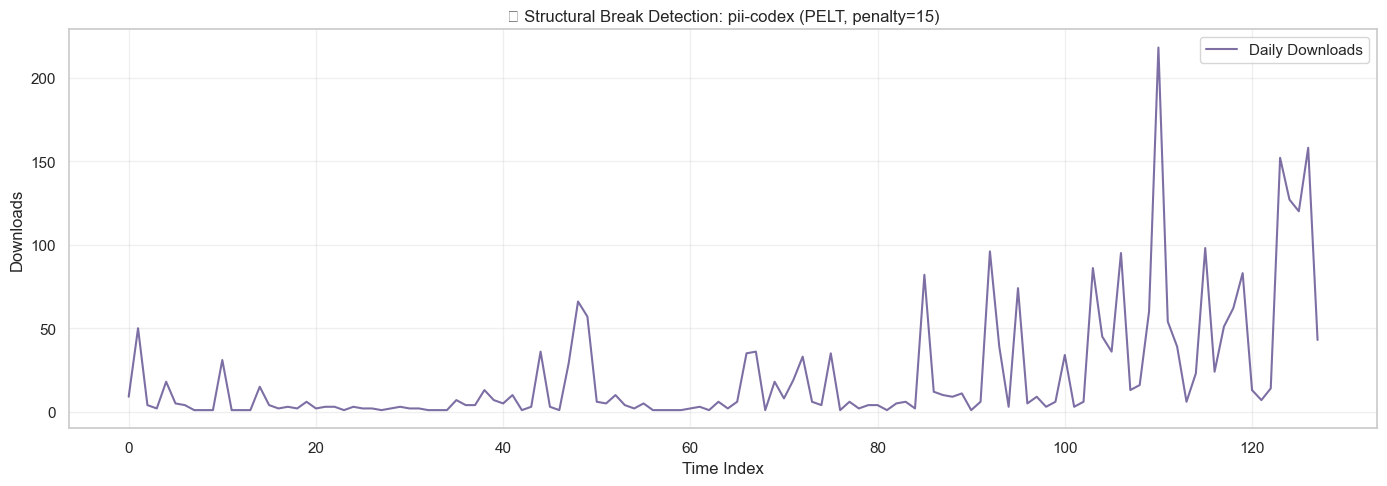

📍 Detected 0 change points for pii-codex
   Break dates: []


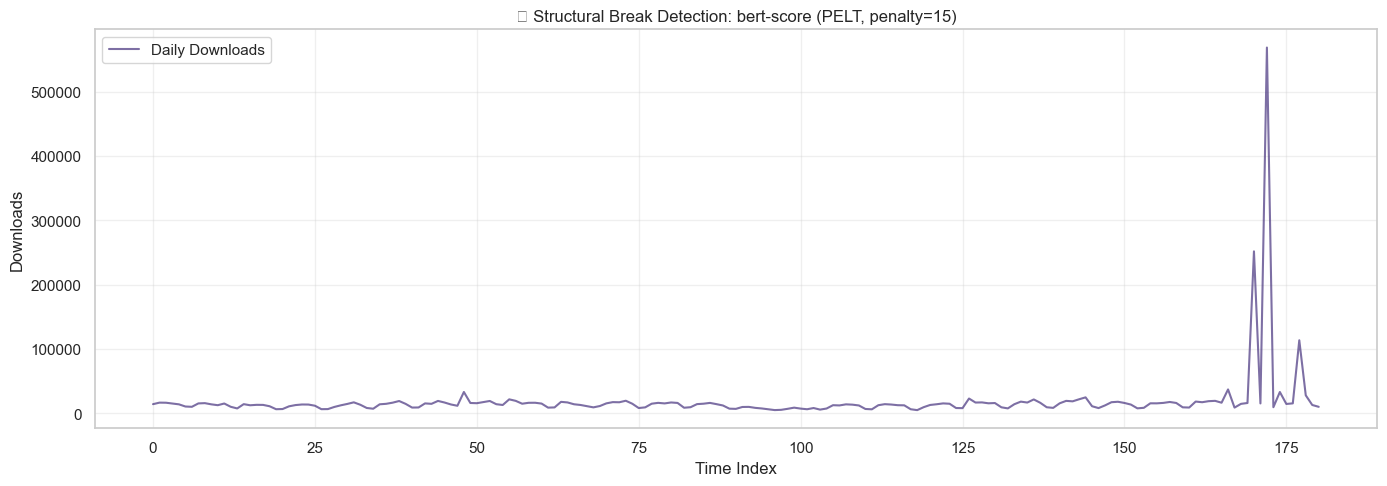

📍 Detected 0 change points for bert-score
   Break dates: []


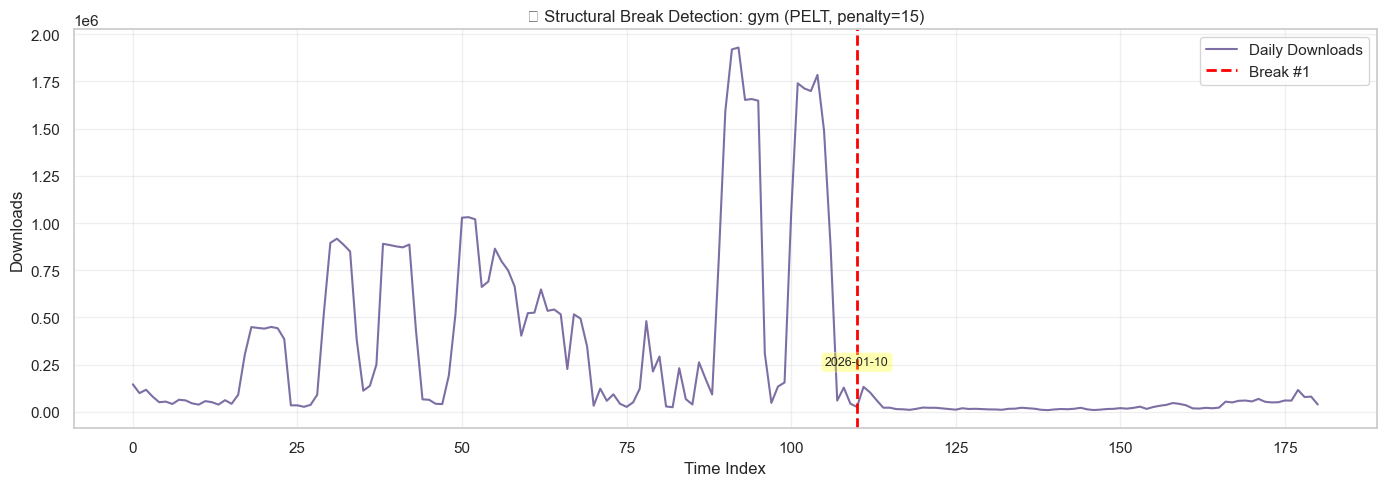

📍 Detected 1 change points for gym
   Break dates: [datetime.date(2026, 1, 10)]


In [57]:
def detect_change_points(pkg_name, penalty=10):
    """Detect structural breaks using PELT algorithm"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna().values
    
    if len(series) < 30:
        return
    
    # PELT algorithm for changepoint detection
    algo = rpt.Pelt(model="rbf").fit(series)
    breaks = algo.predict(pen=penalty)
    
    # Plot with breakpoints
    plt.figure(figsize=(14, 5))
    plt.plot(series, label='Daily Downloads', alpha=0.7)
    for i, bp in enumerate(breaks[:-1]):  # Exclude last (end of series)
        plt.axvline(x=bp, color='red', linestyle='--', linewidth=2, 
                   label=f'Break #{i+1}' if i==0 else "")
        # Annotate with date if possible
        if bp < len(pkg_data):
            bp_date = pkg_data.index[bp]
            plt.annotate(f'{bp_date.date()}', xy=(bp, series[bp]), 
                        xytext=(0, 30), textcoords='offset points',
                        ha='center', fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    plt.title(f'🔍 Structural Break Detection: {pkg_name} (PELT, penalty={penalty})')
    plt.xlabel('Time Index')
    plt.ylabel('Downloads')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"📍 Detected {len(breaks)-1} change points for {pkg_name}")
    if breaks:
        dates = [pkg_data.index[i].date() for i in breaks[:-1] if i < len(pkg_data)]
        print(f"   Break dates: {dates}")

# Detect breaks for packages with high momentum changes
high_momentum = df_clean.groupby('package_name')['download_momentum_pct'].last().abs().nlargest(5)
for pkg in high_momentum.index:
    if pkg in df_clean['package_name'].values:
        detect_change_points(pkg, penalty=15)

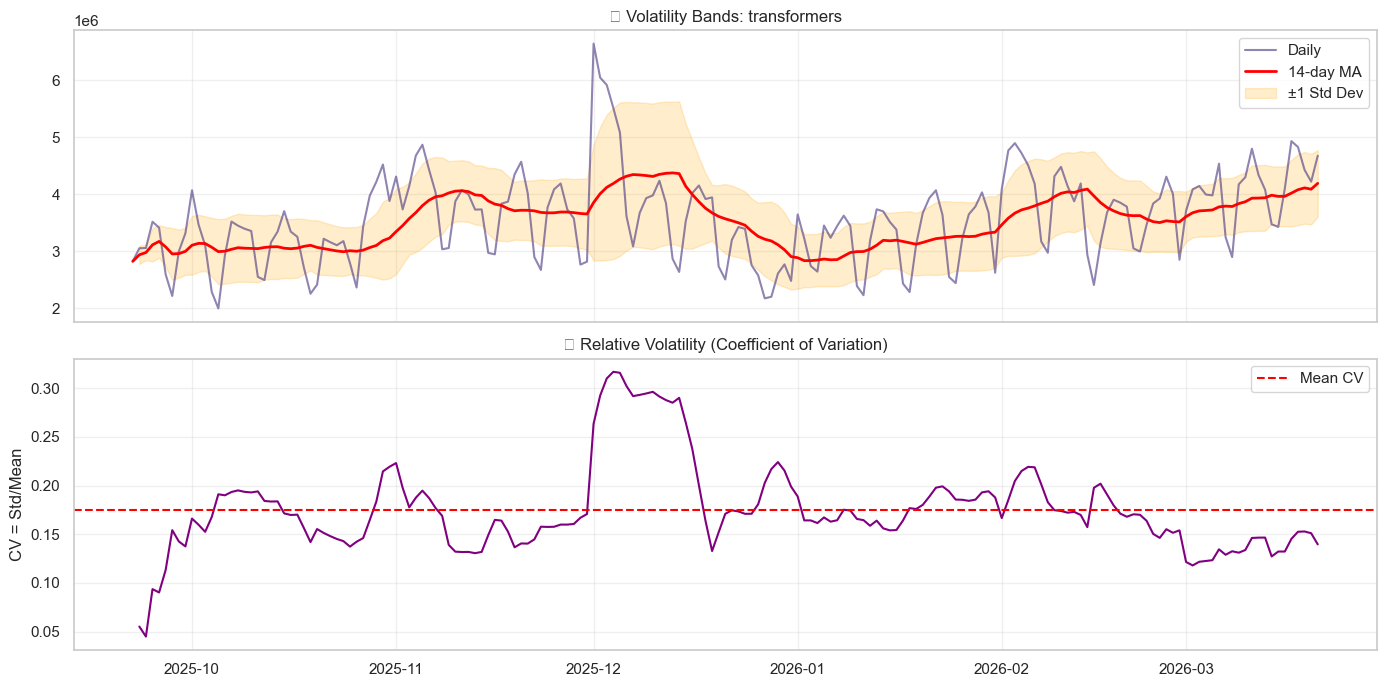

ImportError: cannot import name 'arch_lm' from 'statsmodels.tsa.stattools' (c:\Users\nunye\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py)

In [58]:
def analyze_volatility(pkg_name, window=14):
    """Analyze volatility patterns and test for ARCH effects"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna()
    
    if len(series) < 30:
        return
    
    # Rolling volatility
    pkg_data['rolling_std'] = pkg_data['downloads'].rolling(window=window, min_periods=1).std()
    pkg_data['rolling_mean'] = pkg_data['downloads'].rolling(window=window, min_periods=1).mean()
    pkg_data['cv'] = pkg_data['rolling_std'] / pkg_data['rolling_mean']  # Coefficient of variation
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    
    # Downloads with volatility bands
    axes[0].plot(pkg_data.index, pkg_data['downloads'], alpha=0.6, label='Daily')
    axes[0].plot(pkg_data.index, pkg_data['rolling_mean'], color='red', linewidth=2, label=f'{window}-day MA')
    axes[0].fill_between(pkg_data.index, 
                        pkg_data['rolling_mean'] - pkg_data['rolling_std'],
                        pkg_data['rolling_mean'] + pkg_data['rolling_std'],
                        alpha=0.2, color='orange', label='±1 Std Dev')
    axes[0].set_title(f'📊 Volatility Bands: {pkg_name}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Rolling CV (relative volatility)
    axes[1].plot(pkg_data.index, pkg_data['cv'], color='purple', linewidth=1.5)
    axes[1].axhline(pkg_data['cv'].mean(), color='red', linestyle='--', label='Mean CV')
    axes[1].set_title('📈 Relative Volatility (Coefficient of Variation)')
    axes[1].set_ylabel('CV = Std/Mean')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ARCH-LM test for conditional heteroscedasticity
    from statsmodels.tsa.stattools import arch_lm
    try:
        # Use returns-like transformation: log differences
        log_diff = np.log(pkg_data['downloads'].replace(0, np.nan).dropna()).diff().dropna()
        if len(log_diff) > 20:
            lm_stat, lm_pval, _ = arch_lm(log_diff.values, nlags=5)
            print(f"\n🔬 ARCH-LM Test for {pkg_name}:")
            print(f"   Statistic: {lm_stat:.3f}, p-value: {lm_pval:.4f}")
            if lm_pval < 0.05:
                print("   ✅ Significant volatility clustering detected → Consider GARCH modeling")
            else:
                print("   ❌ No significant ARCH effects")
    except Exception as e:
        print(f"⚠️  ARCH test skipped: {e}")

# Analyze volatility for diverse packages
for pkg in ['transformers', 'langchain', 'matplotlib']:
    if pkg in df_clean['package_name'].values:
        analyze_volatility(pkg)

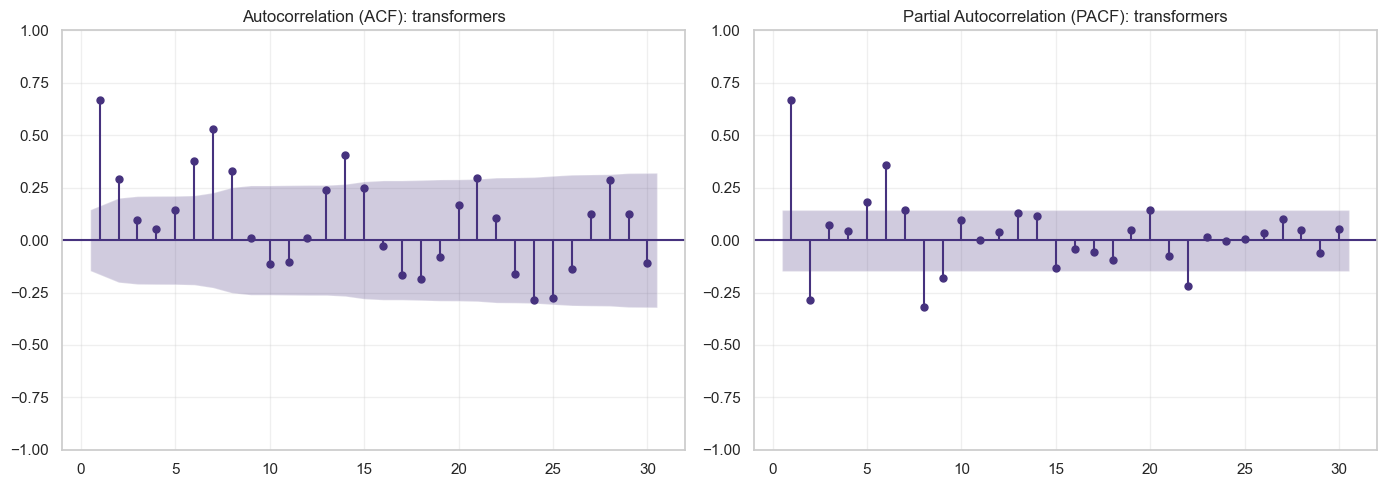


🔍 Ljung-Box Test (White Noise Check) for transformers:


KeyError: 'Lag'

In [ ]:
def plot_acf_pacf(pkg_name, max_lag=30):
    """Plot ACF and PACF for ARIMA model identification"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna()
    
    if len(series) < 50:
        print(f"⚠️  {pkg_name}: Insufficient data for ACF/PACF")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ACF
    plot_acf(series, lags=max_lag, ax=axes[0], title=f'Autocorrelation (ACF): {pkg_name}', zero=False)
    axes[0].grid(alpha=0.3)
    
    # PACF
    plot_pacf(series, lags=max_lag, ax=axes[1], title=f'Partial Autocorrelation (PACF): {pkg_name}', 
              zero=False, method='ywm')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Ljung-Box test for white noise
    lb_results = acorr_ljungbox(series, lags=[7, 14, 21], return_df=True)
    print(f"\n🔍 Ljung-Box Test (White Noise Check) for {pkg_name}:")
    for _, row in lb_results.iterrows():
        lag = int(row['Lag'])
        pval = row['Ljung-Box']
        status = "❌ Not white noise" if pval < 0.05 else "✅ Consistent with white noise"
        print(f"   Lag {lag}: p={pval:.4f} → {status}")

# Check autocorrelation for representative packages
for pkg in ['transformers', 'pandas', 'huggingface-hub']:
    if pkg in df_clean['package_name'].values:
        plot_acf_pacf(pkg)

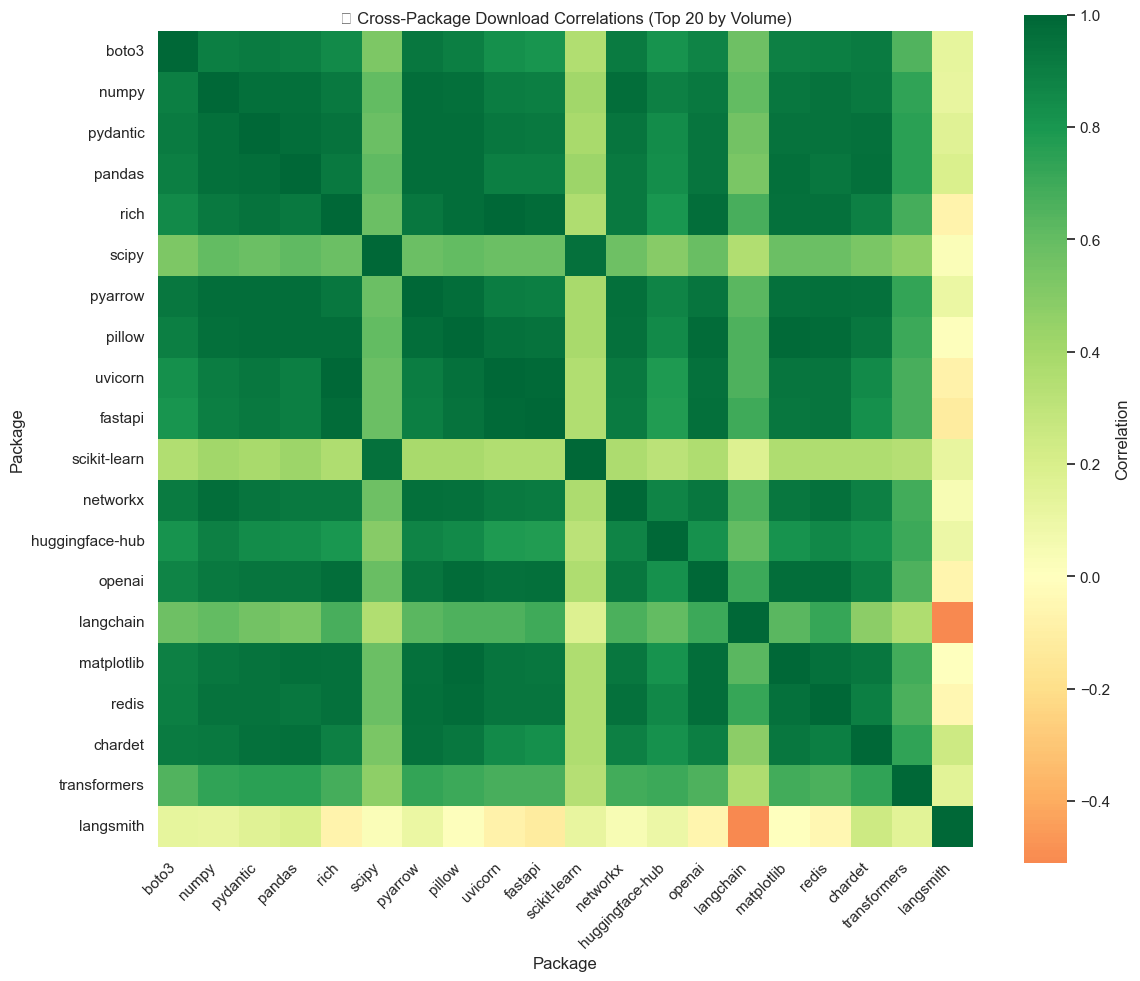


🔗 Highly correlated pairs (|r| > 0.7):
   boto3 ↔ numpy: r = 0.900
   boto3 ↔ pydantic: r = 0.913
   boto3 ↔ pandas: r = 0.897
   boto3 ↔ rich: r = 0.857
   boto3 ↔ pyarrow: r = 0.930
   boto3 ↔ pillow: r = 0.899
   boto3 ↔ uvicorn: r = 0.828
   boto3 ↔ fastapi: r = 0.806
   boto3 ↔ networkx: r = 0.912
   boto3 ↔ huggingface-hub: r = 0.812


In [ ]:
# 🌐 Cross-package correlation: Do popular packages move together?
# Create pivot: date × package with downloads
pivot_downloads = df_clean.pivot_table(index='date', columns='package_name', 
                                       values='downloads', aggfunc='sum').fillna(0)

# Correlation matrix for top 20 packages by volume
top_20 = pivot_downloads.sum().nlargest(20).index
corr_matrix = pivot_downloads[top_20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', center=0, 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('🔗 Cross-Package Download Correlations (Top 20 by Volume)')
plt.xlabel('Package')
plt.ylabel('Package')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Highlight highly correlated pairs
high_corr = []
for i in range(len(top_20)):
    for j in range(i+1, len(top_20)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr.append((top_20[i], top_20[j], corr_val))

if high_corr:
    print(f"\n🔗 Highly correlated pairs (|r| > 0.7):")
    for pkg1, pkg2, corr in high_corr[:10]:  # Show top 10
        print(f"   {pkg1} ↔ {pkg2}: r = {corr:.3f}")

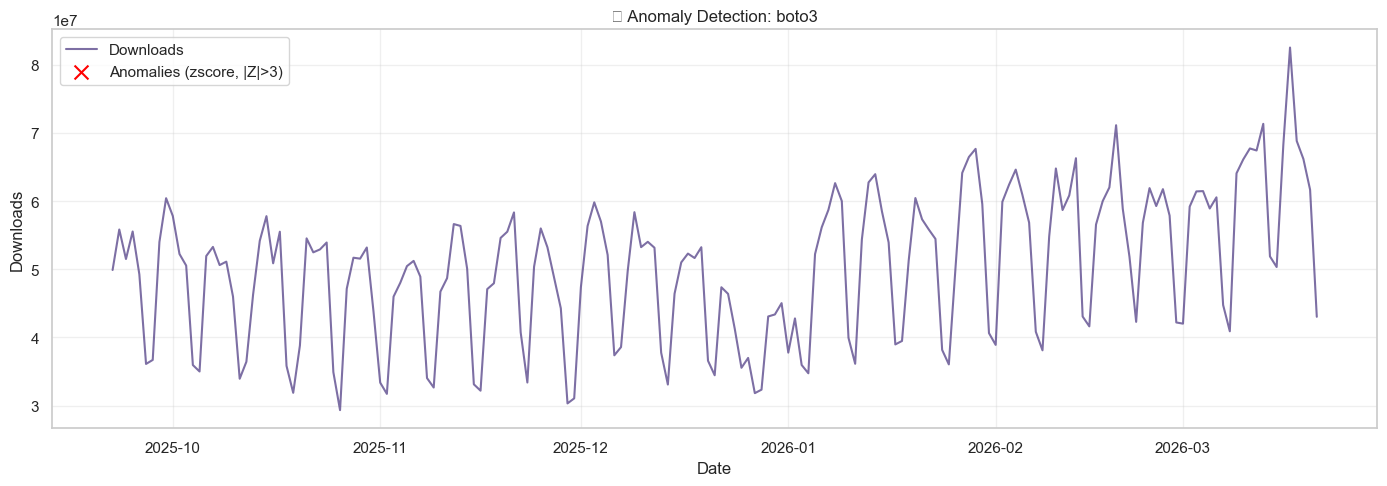

🔍 Detected 0 anomalies in boto3


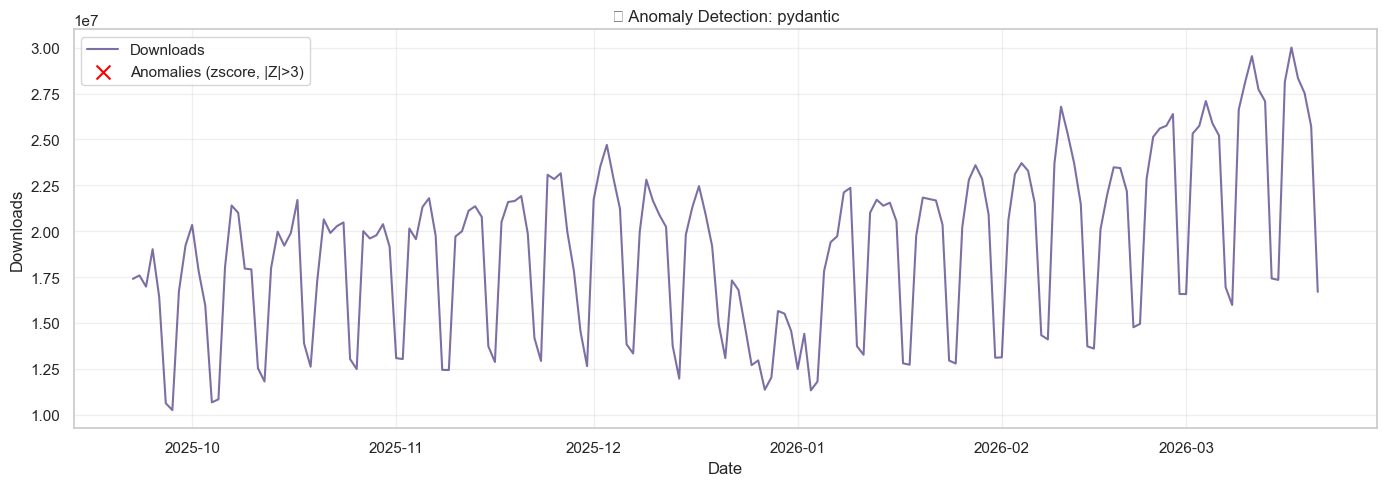

🔍 Detected 0 anomalies in pydantic


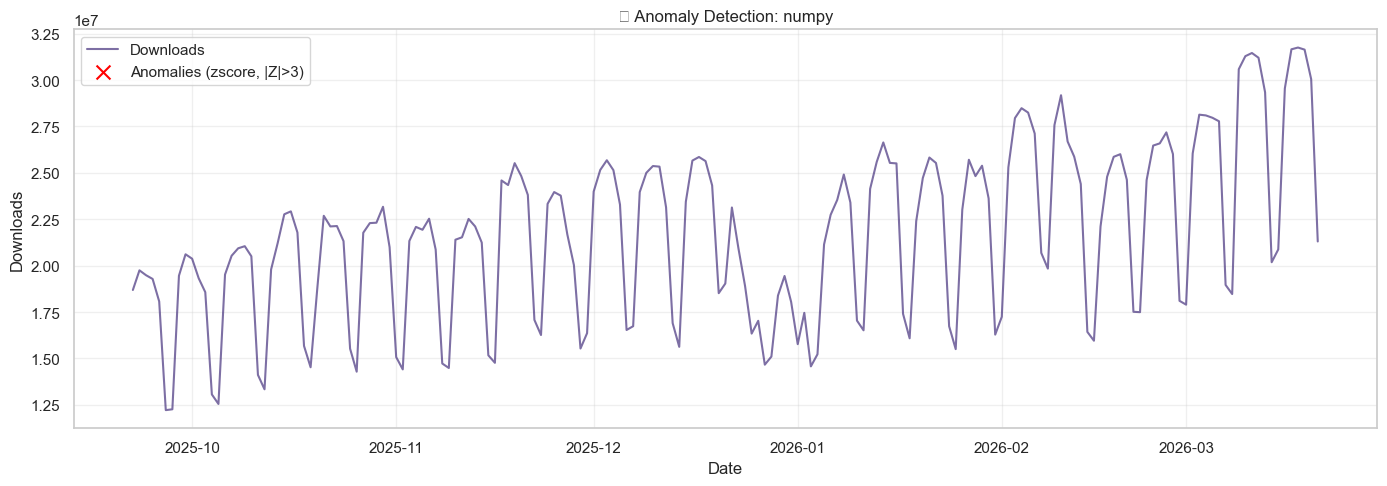

🔍 Detected 0 anomalies in numpy


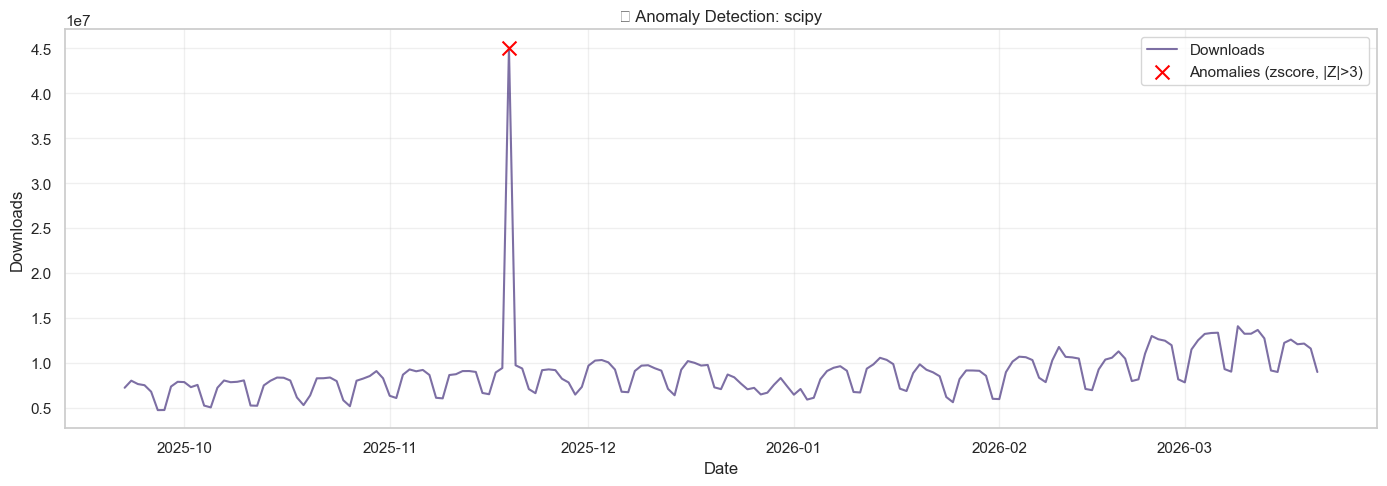

🔍 Detected 1 anomalies in scipy
   Top anomalies:


KeyError: "['upper'] not in index"

In [ ]:
def detect_anomalies(pkg_name, method='zscore', threshold=3):
    """Detect anomalies using multiple methods"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna()
    
    if len(series) < 30:
        return
    
    pkg_data_clean = pkg_data.copy()
    
    if method == 'zscore':
        # Rolling Z-score method
        window = 14
        pkg_data_clean['rolling_mean'] = pkg_data_clean['downloads'].rolling(window, min_periods=1).mean()
        pkg_data_clean['rolling_std'] = pkg_data_clean['downloads'].rolling(window, min_periods=1).std()
        pkg_data_clean['z_score'] = (pkg_data_clean['downloads'] - pkg_data_clean['rolling_mean']) / pkg_data_clean['rolling_std']
        anomalies = pkg_data_clean[np.abs(pkg_data_clean['z_score']) > threshold]
        
    elif method == 'iqr':
        # IQR method on rolling window
        window = 14
        pkg_data_clean['rolling_median'] = pkg_data_clean['downloads'].rolling(window, min_periods=1).median()
        pkg_data_clean['rolling_iqr'] = pkg_data_clean['downloads'].rolling(window, min_periods=1).apply(
            lambda x: np.percentile(x, 75) - np.percentile(x, 25))
        pkg_data_clean['lower'] = pkg_data_clean['rolling_median'] - 1.5 * pkg_data_clean['rolling_iqr']
        pkg_data_clean['upper'] = pkg_data_clean['rolling_median'] + 1.5 * pkg_data_clean['rolling_iqr']
        anomalies = pkg_data_clean[(pkg_data_clean['downloads'] < pkg_data_clean['lower']) | 
                                  (pkg_data_clean['downloads'] > pkg_data_clean['upper'])]
    
    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(pkg_data_clean.index, pkg_data_clean['downloads'], alpha=0.7, label='Downloads')
    plt.scatter(anomalies.index, anomalies['downloads'], color='red', s=100, zorder=5, 
               label=f'Anomalies ({method}, |Z|>{threshold})', marker='x')
    plt.title(f'🚨 Anomaly Detection: {pkg_name}')
    plt.xlabel('Date')
    plt.ylabel('Downloads')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"🔍 Detected {len(anomalies)} anomalies in {pkg_name}")
    if len(anomalies) > 0:
        print("   Top anomalies:")
        print(anomalies[['downloads', 'z_score' if 'z_score' in anomalies.columns else 'lower', 'upper']].head())

# Detect anomalies for packages with high variance
high_var_pkgs = df_clean.groupby('package_name')['downloads'].std().nlargest(5).index
for pkg in high_var_pkgs:
    if pkg in df_clean['package_name'].values:
        detect_anomalies(pkg, method='zscore')

In [ ]:
# 🎯 Bonus: Isolation Forest for multivariate anomaly detection
from sklearn.ensemble import IsolationForest

def multivariate_anomalies(pkg_name):
    """Use multiple features to detect anomalies"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].copy()
    if len(pkg_data) < 50:
        return
    
    # Feature engineering
    pkg_data = pkg_data.set_index('date').asfreq('D').fillna(method='ffill')
    pkg_data['lag1'] = pkg_data['downloads'].shift(1)
    pkg_data['lag7'] = pkg_data['downloads'].shift(7)
    pkg_data['rolling_mean_7'] = pkg_data['downloads'].rolling(7).mean()
    pkg_data['rolling_std_7'] = pkg_data['downloads'].rolling(7).std()
    
    features = ['downloads', 'lag1', 'lag7', 'rolling_mean_7', 'rolling_std_7']
    X = pkg_data[features].dropna()
    
    # Fit Isolation Forest
    clf = IsolationForest(contamination=0.05, random_state=42)
    pkg_data['anomaly_score'] = clf.fit_predict(X[features])
    anomalies = pkg_data[pkg_data['anomaly_score'] == -1]
    
    print(f"🌲 Isolation Forest: {len(anomalies)} anomalies detected in {pkg_name} (5% contamination)")
    return anomalies

# Example for one package
if 'transformers' in df_clean['package_name'].values:
    anomalies_if = multivariate_anomalies('transformers')

ValueError: Length of values (174) does not match length of index (181)


🔍 Stationarity Analysis: transformers

📊 Original Series:
   ADF: stat=-1.930, p=0.3180 → ❌ Non-stationary
   KPSS: stat=0.159, p=0.0396 → ❌ Non-stationary

📊 Log Transformed:
   ADF: stat=-1.809, p=0.3761 → ❌ Non-stationary
   KPSS: stat=0.183, p=0.0223 → ❌ Non-stationary

📊 Diff(1) Transformed:
   ADF: stat=-4.628, p=0.0001 → ✅ Stationary
   KPSS: stat=0.153, p=0.0441 → ❌ Non-stationary

📊 Log-Diff Transformed:
   ADF: stat=-4.791, p=0.0001 → ✅ Stationary
   KPSS: stat=0.164, p=0.0353 → ❌ Non-stationary

📊 Diff(2) Transformed:
   ADF: stat=-6.952, p=0.0000 → ✅ Stationary
   KPSS: stat=0.217, p=0.0100 → ❌ Non-stationary


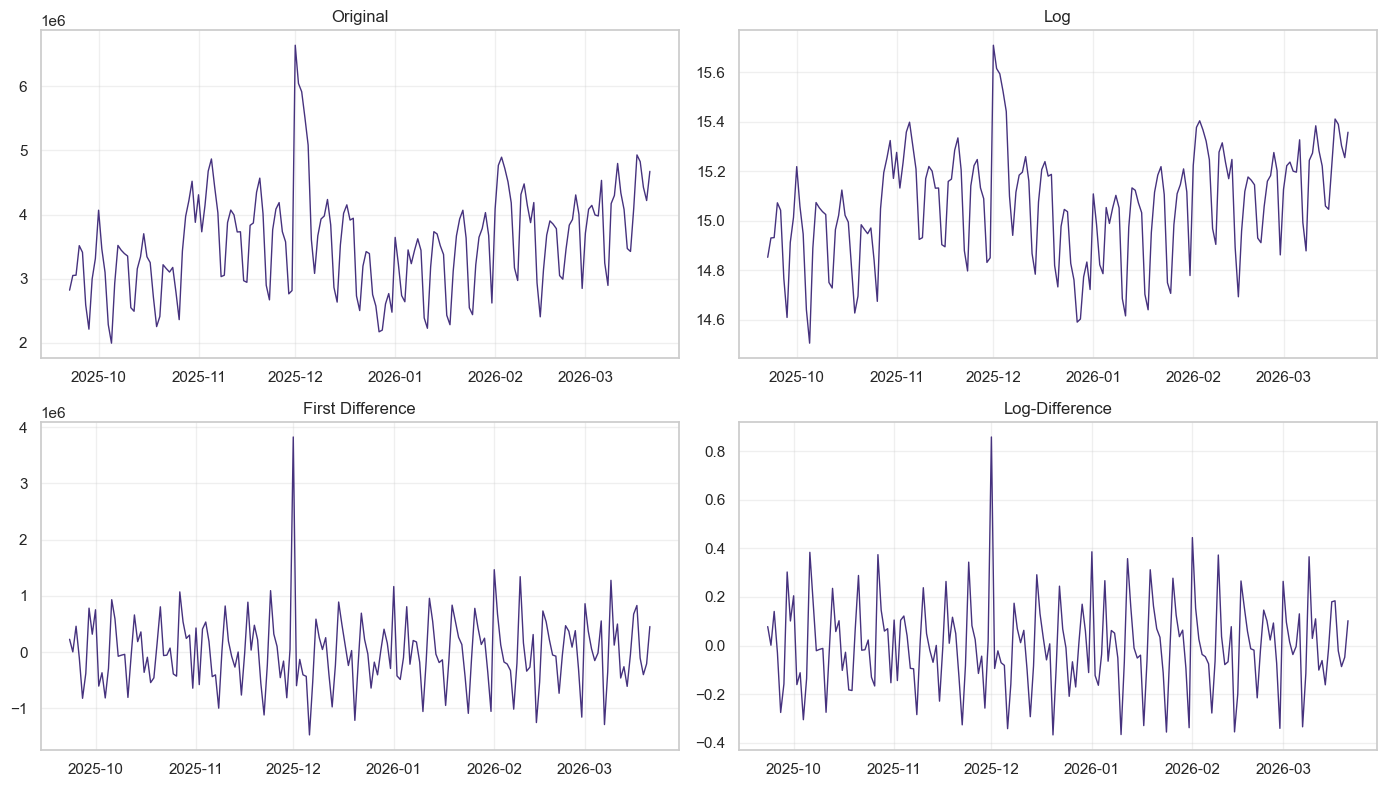


🔍 Stationarity Analysis: torch

📊 Original Series:
   ADF: stat=-1.546, p=0.5106 → ❌ Non-stationary
   KPSS: stat=0.276, p=0.0100 → ❌ Non-stationary

📊 Log Transformed:
   ADF: stat=-1.756, p=0.4024 → ❌ Non-stationary
   KPSS: stat=0.278, p=0.0100 → ❌ Non-stationary

📊 Diff(1) Transformed:
   ADF: stat=-3.679, p=0.0044 → ✅ Stationary
   KPSS: stat=0.276, p=0.0100 → ❌ Non-stationary

📊 Log-Diff Transformed:
   ADF: stat=-4.218, p=0.0006 → ✅ Stationary
   KPSS: stat=0.222, p=0.0100 → ❌ Non-stationary

📊 Diff(2) Transformed:
   ADF: stat=-7.648, p=0.0000 → ✅ Stationary
   KPSS: stat=0.301, p=0.0100 → ❌ Non-stationary


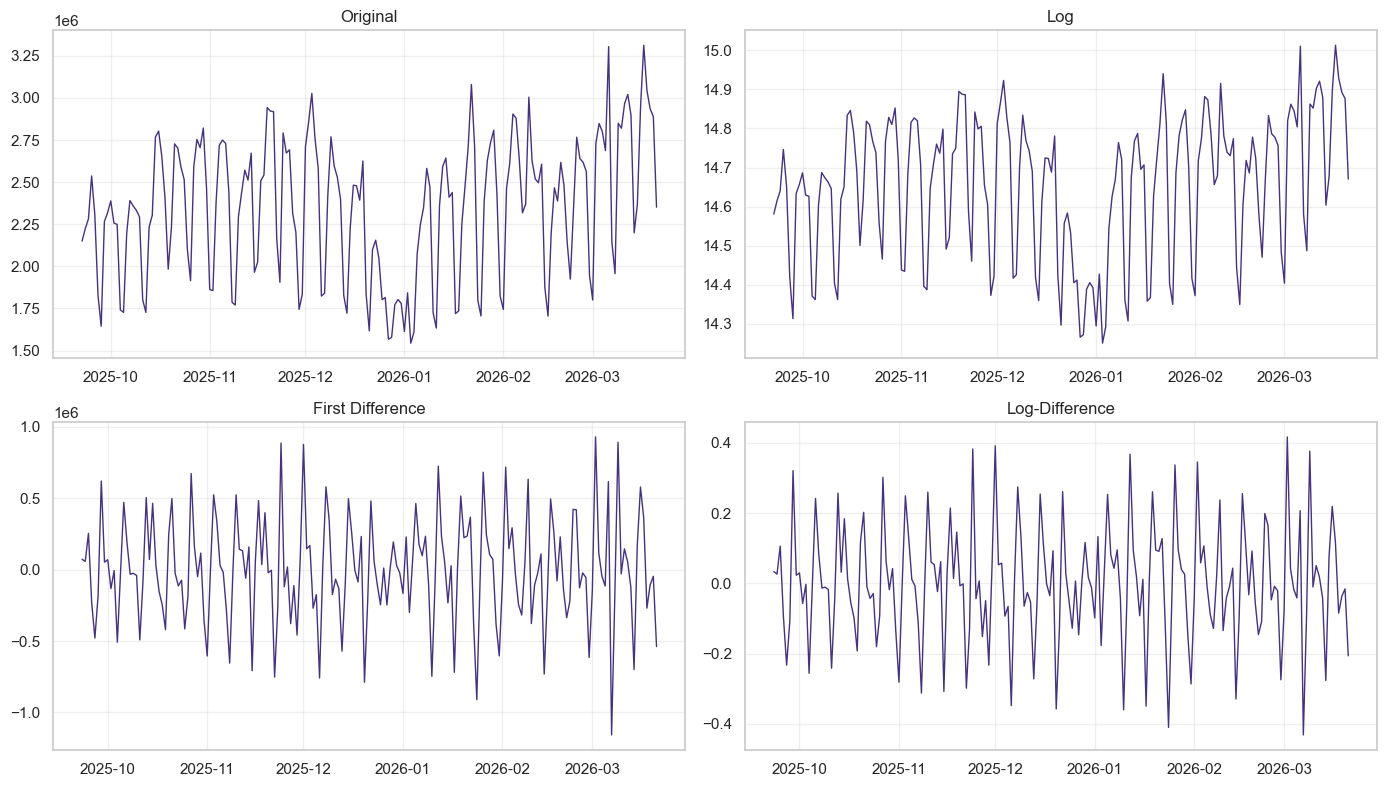


🔍 Stationarity Analysis: scikit-learn

📊 Original Series:
   ADF: stat=-11.833, p=0.0000 → ✅ Stationary
   KPSS: stat=0.090, p=0.1000 → ✅ Stationary

📊 Log Transformed:
   ADF: stat=-1.471, p=0.5477 → ❌ Non-stationary
   KPSS: stat=0.136, p=0.0679 → ✅ Stationary

📊 Diff(1) Transformed:
   ADF: stat=-8.966, p=0.0000 → ✅ Stationary
   KPSS: stat=0.476, p=0.0100 → ❌ Non-stationary

📊 Log-Diff Transformed:
   ADF: stat=-7.040, p=0.0000 → ✅ Stationary
   KPSS: stat=0.192, p=0.0190 → ❌ Non-stationary

📊 Diff(2) Transformed:
   ADF: stat=-7.599, p=0.0000 → ✅ Stationary
   KPSS: stat=0.500, p=0.0100 → ❌ Non-stationary


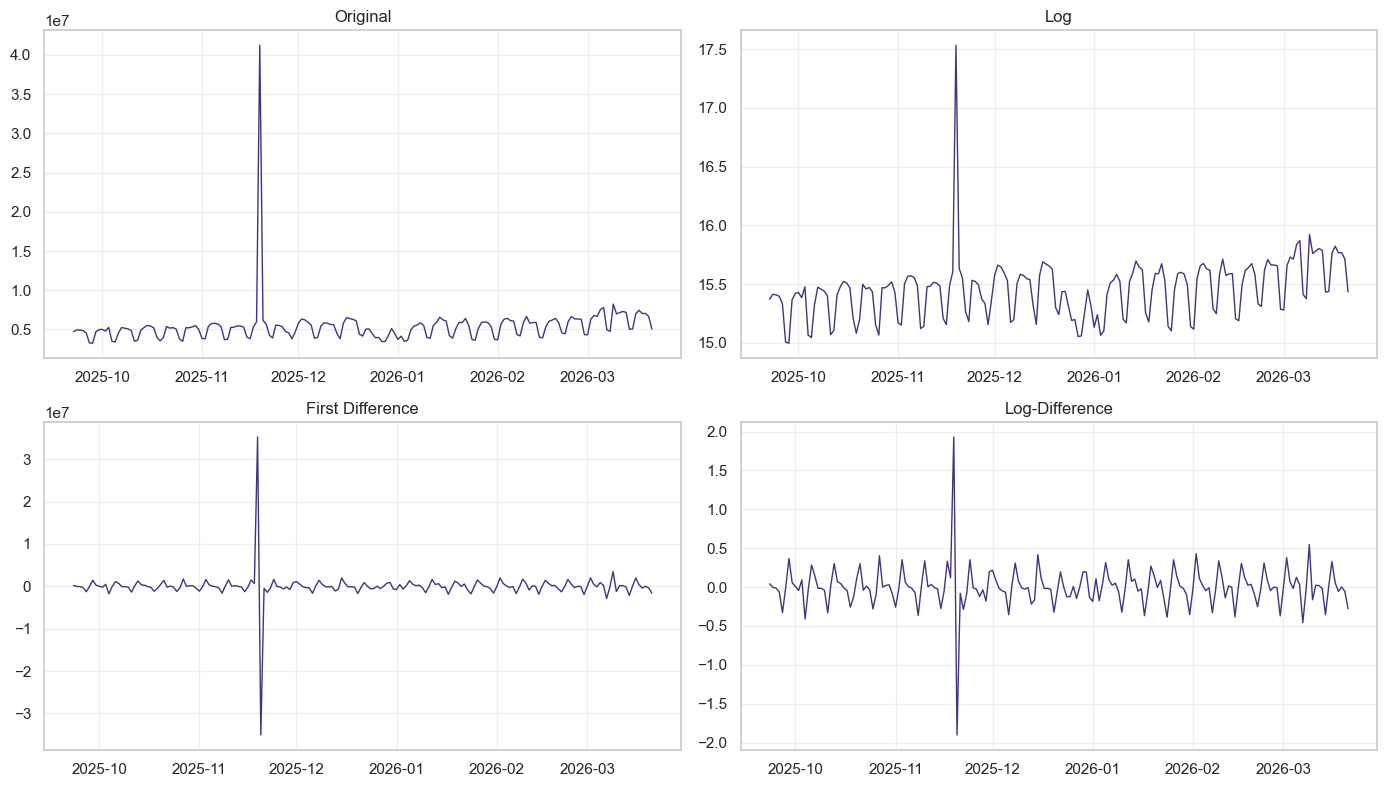

In [ ]:
def comprehensive_stationarity_test(pkg_name):
    """Full stationarity analysis with transformations"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    series = pkg_data['downloads'].dropna()
    
    if len(series) < 50:
        print(f"⚠️  {pkg_name}: Insufficient data")
        return
    
    print(f"\n{'='*60}")
    print(f"🔍 Stationarity Analysis: {pkg_name}")
    print(f"{'='*60}")
    
    def run_tests(data, label):
        print(f"\n📊 {label}:")
        # ADF Test
        adf_result = adfuller(data.dropna(), autolag='AIC')
        print(f"   ADF: stat={adf_result[0]:.3f}, p={adf_result[1]:.4f} → {'✅ Stationary' if adf_result[1]<0.05 else '❌ Non-stationary'}")
        # KPSS Test
        kpss_result = kpss(data.dropna(), regression='ct', nlags='auto')
        print(f"   KPSS: stat={kpss_result[0]:.3f}, p={kpss_result[1]:.4f} → {'✅ Stationary' if kpss_result[1]>0.05 else '❌ Non-stationary'}")
        return adf_result[1], kpss_result[1]
    
    # Test original
    adf_p, kpss_p = run_tests(series, "Original Series")
    
    # Test transformations
    transformations = {
        'Log': np.log(series.replace(0, np.nan).dropna() + 1e-9),
        'Diff(1)': series.diff().dropna(),
        'Log-Diff': np.log(series.replace(0, np.nan).dropna() + 1e-9).diff().dropna(),
        'Diff(2)': series.diff().diff().dropna()
    }
    
    for name, transformed in transformations.items():
        if len(transformed) > 30:
            run_tests(transformed, f"{name} Transformed")
    
    # Plot transformations
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plots = [
        (series, 'Original', axes[0,0]),
        (np.log(series.replace(0, np.nan).dropna() + 1e-9), 'Log', axes[0,1]),
        (series.diff().dropna(), 'First Difference', axes[1,0]),
        (np.log(series.replace(0, np.nan).dropna() + 1e-9).diff().dropna(), 'Log-Difference', axes[1,1])
    ]
    
    for data, title, ax in plots:
        if len(data) > 0:
            ax.plot(data.index if hasattr(data, 'index') else range(len(data)), 
                   data.values if hasattr(data, 'values') else data, linewidth=1)
            ax.set_title(title)
            ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run for key packages
for pkg in ['transformers', 'torch', 'scikit-learn']:
    if pkg in df_clean['package_name'].values:
        comprehensive_stationarity_test(pkg)

In [ ]:
def generate_package_summary(pkg_name):
    """Generate comprehensive summary for one package"""
    pkg_data = df_clean[df_clean['package_name'] == pkg_name].set_index('date').asfreq('D')
    
    summary = {
        'package': pkg_name,
        'date_range': f"{pkg_data.index.min().date()} to {pkg_data.index.max().date()}",
        'total_days': len(pkg_data),
        'total_downloads': pkg_data['downloads'].sum(),
        'avg_daily': pkg_data['downloads'].mean(),
        'std_daily': pkg_data['downloads'].std(),
        'cv': pkg_data['downloads'].std() / pkg_data['downloads'].mean(),
        'trend_direction': '↑' if pkg_data['downloads'].iloc[-7:].mean() > pkg_data['downloads'].iloc[:7].mean() else '↓',
        'weekly_pattern': pkg_data.groupby('dayofweek')['downloads'].mean().idxmax(),
        'missing_days': pkg_data['downloads'].isna().sum()
    }
    
    print(f"\n📋 Summary: {summary['package']}")
    print(f"   📅 {summary['date_range']} ({summary['total_days']} days)")
    print(f"   📦 Total: {summary['total_downloads']:,} | Avg: {summary['avg_daily']:,.0f}/day")
    print(f"   📊 Volatility: CV = {summary['cv']:.2f} (std/mean)")
    print(f"   📈 Trend: {summary['trend_direction']} | Peak day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][summary['weekly_pattern']]}")
    print(f"   🕳️  Missing: {summary['missing_days']} days")
    
    return summary

# Generate summaries for top packages
print("🎯 TOP PACKAGES EDA SUMMARY")
print("="*50)
summaries = []
for pkg in top_packages.index[:10]:
    summaries.append(generate_package_summary(pkg))

# Create summary DataFrame
summary_df = pd.DataFrame(summaries)
print("\n📊 Summary Table:")
print(summary_df[['package', 'total_downloads', 'avg_daily', 'cv', 'trend_direction']].to_string(index=False))

🎯 TOP PACKAGES EDA SUMMARY

📋 Summary: boto3
   📅 2025-09-22 to 2026-03-21 (181 days)
   📦 Total: 9,073,946,833 | Avg: 50,132,303/day
   📊 Volatility: CV = 0.21 (std/mean)
   📈 Trend: ↑ | Peak day: Tue
   🕳️  Missing: 0 days

📋 Summary: numpy
   📅 2025-09-22 to 2026-03-21 (181 days)
   📦 Total: 3,922,209,344 | Avg: 21,669,665/day
   📊 Volatility: CV = 0.21 (std/mean)
   📈 Trend: ↑ | Peak day: Wed
   🕳️  Missing: 0 days

📋 Summary: pydantic
   📅 2025-09-22 to 2026-03-21 (181 days)
   📦 Total: 3,445,408,314 | Avg: 19,035,405/day
   📊 Volatility: CV = 0.24 (std/mean)
   📈 Trend: ↑ | Peak day: Wed
   🕳️  Missing: 0 days

📋 Summary: pandas
   📅 2025-09-22 to 2026-03-21 (181 days)
   📦 Total: 3,002,398,739 | Avg: 16,587,838/day
   📊 Volatility: CV = 0.18 (std/mean)
   📈 Trend: ↑ | Peak day: Tue
   🕳️  Missing: 0 days

📋 Summary: rich
   📅 2025-09-22 to 2026-03-21 (181 days)
   📦 Total: 1,758,994,955 | Avg: 9,718,204/day
   📊 Volatility: CV = 0.31 (std/mean)
   📈 Trend: ↑ | Peak day: Tue
   🕳